<a href="https://colab.research.google.com/github/jrapakko/cse11b/blob/main/Introduction_to_spaCy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction to spaCy

**You do not need to submit this Notebook.** It is for practice only.

This Notebook is intended to provide a brief introduction to the spaCy NLP library, which we will be using throughout this course.

### Learn by Experimenting
Please do not simply click "Run all" at the top before reading, as much of the value of this document is to serve as an interactive exploration from one section to the next. In fact, it will help significantly with learning if you first try to understand what the code in a cell might be doing before you run it and get the answer.

Additionally, as you read through the Notebook, you are highly encouraged to change the values in cells to see how the output changes when the cells are re-run. In doing so, you will gain a better understanding of how the various operations behave.

### Notebook Troubleshooting
If you get an unexpected error, the fix is often to click "Run before" from the Runtime menu to run all cells prior to the currently selected cell. If the error persists and you are not sure how to continue, please post on our Canvas forum or send me a message directly with information about the problem.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import spacy

### Visualization Libraries

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Language Model
In order to use spaCy, we need to specify a language model. Here, we use a small (`sm`) English language model ideal for experimentation and prototyping.

By spaCy convention, the language model is stored in a variable named `nlp`.

In [3]:
nlp = spacy.load("en_core_web_sm")

## Create a Document
In NLP terminology, a **document** is a chunk of text. Using spaCy, we create a `Doc` object by passing a string containing our document to the language model.

This `Doc` object will automatically preprocess the text and, as we will see shortly, provide access to many convenient functions and attributes for that text.

In [4]:
apollo_text = """
On July 20, 1969, at 10:56 p.m. EDT, astronaut Neil Armstrong of NASA stepped
onto the Moon during the Apollo 11 mission, watched by millions in the United
States."""

apollo_doc = nlp(apollo_text)

### Inspecting Token Attributes
The `Doc` object created previously generated a `Token` object for each word in the document. These `Token` objects themselves have several attributes, such as:
- `.text` The original string text of the token
- `.lemma_` A normalized (uninflected) form of a word
- `.pos_` The token's part of speech, such as noun or verb
- `.is_stop` Whether the token serves primarily a grammatical rather than semantic purpose, such as a preposition
- `.ent_type_` Whether the token is part of a named entity and, if so, the type of the entity, such as an organization's name

We will discuss the meanings of lemmas, parts of speech, stop words, and named entities in more detail in the next module.



We can take our document and iterate through each of the tokens using the simple spaCy idiom below (replacing `...` with any code we want to run inside the loop).

```python
  for token in doc:
      ...
```

Let's use our current document to create a Pandas DataFrame to display the values of the different attributes for each token in the document. (I name the `.is_stop` column as `"filter?"` because this Boolean value is often used to filter out grammatical words.)

In [5]:
rows = []
for token in apollo_doc:
    rows.append([token.text, token.lemma_, token.pos_, token.is_stop, token.ent_type_])
df = pd.DataFrame(rows, columns=["text", "lemma", "pos", "filter?", "entity"])
df

,text,lemma,pos,filter?,entity
0,\n,\n,SPACE,False,
1,On,on,ADP,True,
2,July,July,PROPN,False,DATE
3,20,20,NUM,False,DATE
4,",",",",PUNCT,False,DATE
5,1969,1969,NUM,False,DATE
6,",",",",PUNCT,False,
7,at,at,ADP,True,
8,10:56,10:56,NUM,False,TIME
9,p.m.,p.m.,ADV,False,TIME


In a later activity, we will see how to meaningfully apply many of these attributes to a particular task.

## Word Embeddings

It is often useful to compare tokens or documents for similarity (or dissimilarity), such as for information retrieval applications. To compare text for similarity, we first represent it numerically.

One way of establishing numerical representations of text is using embeddings, which are vectors (arrays of real numbers) iteratively tuned by a neural network. Once these vectors are sufficiently tuned, they can be easily applied for various purposes.

Because the inclusion of these embeddings increases the size of the language model, they are not included in the `en_core_web_sm` model loaded previously.

### Download the Medium-Sized English Language Model

The medium-sized model, `en_core_web_md`, provides each token with a pre-trained word embedding.

In [6]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 56.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### Load the Downloaded Language Model

Although `nlp` is spaCy's language model naming convention, here I use `nlp_md` so as to not overwrite the previous variable.

In [7]:
nlp_md = spacy.load("en_core_web_md")

### Preprocess a New Document

For the purpose of comparing the similarity of words, let's change our document text.

Below is the mission statement of Foothill College.

In [8]:
mission_text = """
Embracing inclusivity and building strong communities, Foothill College serves
diverse learners and equips its students with critical thinking skills to
address complex societal challenges, to thrive in the global workforce, and to
engage in a life of inquiry.
"""

mission_doc = nlp_md(mission_text)

### Filtering the Tokens

For this exploration, it would not be meaningful to include tokens representing spaces, punctuation, or common grammatical (stop) words.

Below, we filter out unwanted token types using a [Python list comprehension](https://docs.python.org/3/tutorial/datastructures.html#list-comprehensions).

In [9]:
tokens = [
    token for token in mission_doc
    if not (
        token.is_stop
        or token.pos_ == "PUNCT"
        or token.text.isspace()
    )
]

tokens

[Embracing,
 inclusivity,
 building,
 strong,
 communities,
 Foothill,
 College,
 serves,
 diverse,
 learners,
 equips,
 students,
 critical,
 thinking,
 skills,
 address,
 complex,
 societal,
 challenges,
 thrive,
 global,
 workforce,
 engage,
 life,
 inquiry]

#### Python String Filter Methods

Although this course will not focus on the Python language itself, some methods will be very helpful in creating NLP projects. Here, we look at how to filter strings based on the types of characters they contain.

Before running the code below, try to guess what will be displayed.

In [10]:
for token in apollo_doc:
    if token.text.isalpha():
        print(token.text)

On
July
at
EDT
astronaut
Neil
Armstrong
of
NASA
stepped
onto
the
Moon
during
the
Apollo
mission
watched
by
millions
in
the
United
States


There are several Python string methods useful for filtering. The following functions return `True` if the condition is met, otherwise they return `False`.
- `isalnum` All string characters are alphanumeric (letters or numbers)
- `isalpha` All string characters are alphabetic (letters only)
- `isdigit` All string characters are numbers
- `islower` All string characters are lowercase
- `isupper` All string characters are uppercase
- `isspace` All string characters are spaces

If you want the opposite of a particular result - say, all strings that do **not** have numbers, use the `not` keyword before the function call.

For more string functions, see the [Python documentation](https://docs.python.org/3/builtins/stdtypes.html#string-methods).

#### Duplicate Tokens

If your document contains duplicate words - which is common but not an issue for this example - you will want to collect only unique token text to avoid measuring similarities between words more than once. Use a Python `set` to remove duplicates from a list.

```python
>>> set([1, 2, 2, 3, 3, 3])
{1, 2, 3}
```

### Creating a Similarity Matrix

The code below iterates through the list of tokens twice; for each row (the outer loop), it iterates through the tokens (the inner loop) to calculate the similarity of the inner loop's token with the current row's token. The lists are wrapped up in a DataFrame to enhance presentation.

We will discuss similarity metrics in a future module. For now, just know that here a value of `1.0` means the words are identical, and a value of `-1.0` means the words represent maximum dissimilarity.

In [11]:
token_text = [token.text.lower() for token in tokens]

rows = []
for row_token in tokens:
    row = []
    for col_token in tokens:
        row.append(row_token.similarity(col_token))
    rows.append(row)

df = pd.DataFrame(rows, index=token_text, columns=token_text)
df

,embracing,inclusivity,building,strong,communities,foothill,college,serves,diverse,learners,...,address,complex,societal,challenges,thrive,global,workforce,engage,life,inquiry
embracing,1.000000,0.325767,0.277126,0.332591,0.539690,-0.011569,0.090337,0.294654,0.343430,0.117406,...,0.320835,0.242125,0.360311,0.373734,0.331064,0.381113,0.257675,0.320835,1.000000,0.185802
inclusivity,0.325767,1.000000,0.096394,0.314377,0.257667,0.150378,0.068168,0.486435,0.383767,0.260579,...,0.184390,0.202037,0.331881,0.221119,0.276944,0.346557,0.176893,0.184390,0.325767,0.073269
building,0.277126,0.096394,1.000000,0.301862,0.237924,-0.086581,0.129893,0.262236,0.342710,0.056627,...,0.256414,0.426186,0.235125,0.339891,0.329683,0.251605,0.242469,0.256414,0.277126,0.182255
strong,0.332591,0.314377,0.301862,1.000000,0.290846,-0.131334,0.242488,0.319257,0.409111,0.217215,...,0.377645,0.396049,0.244432,0.256938,0.476187,0.246709,0.257629,0.377645,0.332591,0.129793
communities,0.539690,0.257667,0.237924,0.290846,1.000000,-0.009522,0.063000,0.227122,0.338026,0.174981,...,0.306762,0.237883,0.268648,0.311076,0.283982,0.327599,0.278130,0.306762,0.539690,0.100064
foothill,-0.011569,0.150378,-0.086581,-0.131334,-0.009522,1.000000,-0.032118,-0.095184,-0.144919,0.027586,...,-0.110933,-0.153476,-0.013566,0.004069,-0.060661,-0.042016,-0.023993,-0.110933,-0.011569,0.061929
college,0.090337,0.068168,0.129893,0.242488,0.063000,-0.032118,1.000000,0.124064,0.173535,0.398413,...,0.162294,0.278154,0.108555,0.057871,0.201017,0.048099,0.130077,0.162294,0.090337,0.061485
serves,0.294654,0.486435,0.262236,0.319257,0.227122,-0.095184,0.124064,1.000000,0.768646,0.246731,...,0.287219,0.356725,0.365103,0.268242,0.319976,0.327004,0.288940,0.287219,0.294654,0.136752
diverse,0.343430,0.383767,0.342710,0.409111,0.338026,-0.144919,0.173535,0.768646,1.000000,0.283391,...,0.484906,0.398657,0.323112,0.330881,0.476346,0.318026,0.351458,0.484906,0.343430,0.111605
learners,0.117406,0.260579,0.056627,0.217215,0.174981,0.027586,0.398413,0.246731,0.283391,1.000000,...,0.196097,0.203687,0.156711,0.079156,0.142151,0.203580,0.217755,0.196097,0.117406,0.111915


#### Improving the Visualization

Although visualizations are not a formal part of the course, I may use them on occasion when they support understanding of the data. Know that you are not responsible for learning these techniques for this course, but you might find the code useful for your projects.

Here, we take the similarity matrix from above and represent it as a heatmap, in which opposing values - maximum similarity and maximum dissimilarity - are on opposing ends of a color spectrum.

To avoid cluttering with redundant information, the top half of the matrix is removed (which is the purpose of the `mask`).

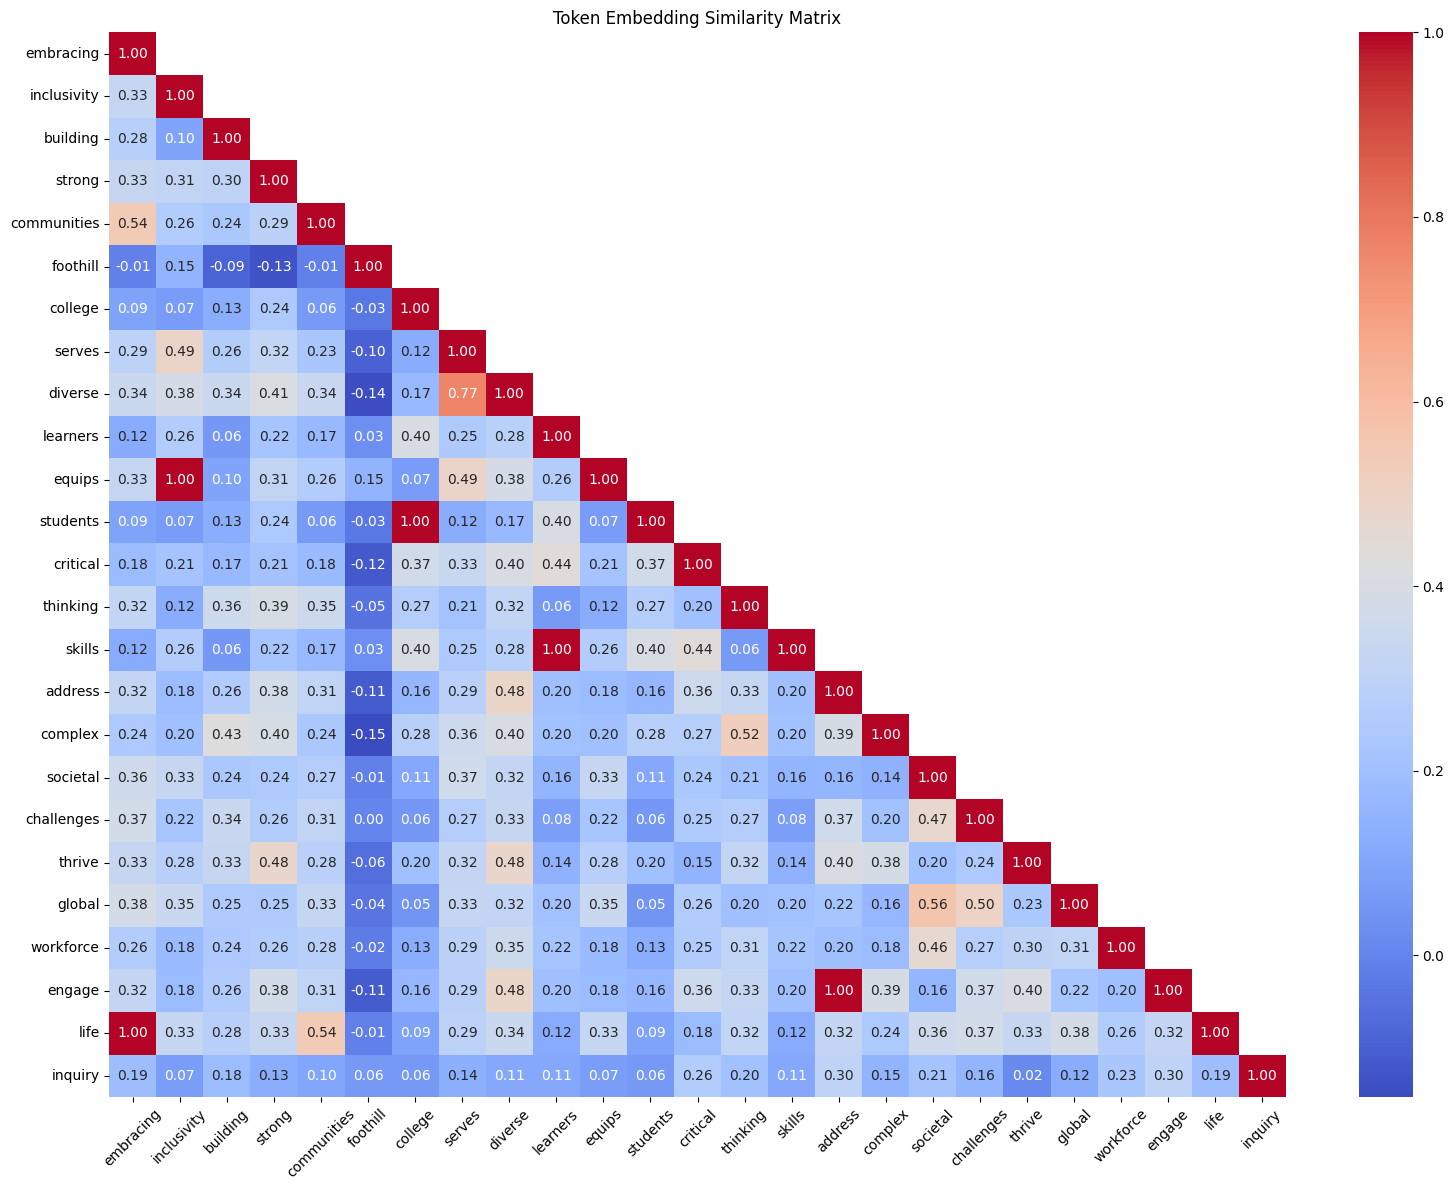

In [12]:
mask = np.triu(np.ones_like(df, dtype=bool), k=1)

plt.figure(figsize=(16, 12))

sns.heatmap(
    df,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Token Embedding Similarity Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Take a look at some of the similarity scores. Are there any that surprise you, given the context in which the words were used?

Keep in mind that contextual similarity measurement is very complicated, and these simple methods can only do so much.

From [spaCy's page on semantic similarity](https://spacy.io/usage/linguistic-features#vectors-similarity):
> Computing similarity scores can be helpful in many situations, but it’s also important to maintain realistic expectations about what information it can provide. Words can be related to each other in many ways, so a single “similarity” score will always be a mix of different signals, and vectors trained on different data can produce very different results that may not be useful for your purpose.

## Visualizers

We'll wrap up with a look at spaCy's entity and dependency visualizers. These features will not be necessary for the course, but they are nonetheless interesting to see.

### Named Entity Visualizer

Here we see the sentence from earlier on the Apollo mission with named entities highlighted and labeled inline with the text.

In [13]:
spacy.displacy.render(apollo_doc, style="ent", jupyter=True)

### Dependency Visualizer

If you ever take a course in linguistics, you'll learn more about how words depend on one another to build grammatical structure. This dependency graph shows relationships such as subjects, objects, and compound phrases.

To more easily understand the graph, let's use a shorter sentence.

In [15]:
short_text = "Foothill is a public community college in Los Altos Hills, California."
doc = nlp(short_text)

In [16]:
spacy.displacy.render(doc, style="dep", jupyter=True)

## Next Steps

In the next module, we will formally begin using spaCy to create a preprocessing pipeline, which will serve as the foundation from which most of our NLP work will build.